# Error Analysis

Categorize wrong predictions with a simple taxonomy:
- **Arithmetic error** — set up correctly, miscalculated
- **Multi-step reasoning failure** — missed/confused reasoning steps
- **Quantity misinterpretation** — grabbed the wrong number from the question
- **Other** — no output, hallucination, etc.

Point `PREDICTION_FILE` to whichever predictions JSON you want to analyze.

In [23]:
import json
import re
import sys
from typing import Set

import matplotlib.pyplot as plt
import pandas as pd

sys.path.insert(0, "..")
from src.evaluate import extract_predicted_answer, extract_ground_truth, is_correct

In [24]:
PREDICTION_FILE = "../results/zeroshot_gpt2.json"

with open(PREDICTION_FILE) as f:
    preds = json.load(f)
print(f"Loaded {len(preds)} predictions")

Loaded 100 predictions


## Overall accuracy

In [25]:
rows = []
for rec in preds:
    pred_text = rec.get("raw_output") or rec.get("prediction", "")
    gold_text = rec.get("gold_answer", "")
    rows.append({
        "index": rec.get("index", 0),
        "question": rec.get("question", ""),
        "gold_answer": gold_text,
        "gold_value": extract_ground_truth(gold_text),
        "predicted_value": extract_predicted_answer(pred_text),
        "raw_output": pred_text,
        "correct": is_correct(pred_text, gold_text),
        "manual_error": rec.get("manual_error_category", "unlabeled")
    })

df = pd.DataFrame(rows)
n_right = df["correct"].sum()
print(f"Accuracy: {n_right}/{len(df)} = {n_right/len(df):.4f}")

Accuracy: 2/100 = 0.0200


In [26]:
wrong = df[~df["correct"]].copy()
print(f"{len(wrong)} wrong predictions")
wrong.head()

98 wrong predictions


,index,question,gold_answer,gold_value,predicted_value,raw_output,correct,manual_error
0,0,Janet’s ducks lay 16 eggs per day. She eats th...,Janet sells 16 - 3 - 4 = <<16-3-4=9>>9 duck eg...,18.0,2.0,$2.50 per duck egg.\n\nQuestion: Janet’s duck...,False,quantity misinterpretation
1,1,A robe takes 2 bolts of blue fiber and half th...,It takes 2/2=<<2/2=1>>1 bolt of white fiber\nS...,3.0,1.0,1 bolt.\n\nQuestion: A robe takes 2 bolts of ...,False,multi-step reasoning failure
2,2,Josh decides to try flipping a house. He buys...,The cost of the house and repairs came out to ...,70000.0,80000.0,"$50,000.\n\nQuestion: Josh decides to try fli...",False,quantity misinterpretation
3,3,James decides to run 3 sprints 3 times a week....,He sprints 3*3=<<3*3=9>>9 times\nSo he runs 9*...,540.0,37.0,1. 2. 3. 4. 5. 6. 7. 8. 9. 10. 11....,False,other
4,4,"Every day, Wendi feeds each of her chickens th...","If each chicken eats 3 cups of feed per day, t...",20.0,29.0,\n\nThe answer is 1. \n\n2. \n\n3. \n\n4. \n\...,False,other


## Heuristic error classification

Automated heuristic to suggest a category. For the report we manually verified a sample.

In [27]:
def _classify_error(row) -> str:
    pred, gold, q = row["predicted_value"], row["gold_value"], row["question"]
    if pred is None or gold is None:
        return "other"

    # did the model just parrot a number from the question?
    q_nums: Set[float] = {float(n) for n in re.findall(r"\d+", q)}
    if pred in q_nums and pred != gold:
        return "quantity_misinterpretation"

    # small relative error -> likely arithmetic slip
    if gold != 0 and abs(pred - gold) / abs(gold) < 0.25:
        return "arithmetic_error"

    return "multistep_failure"


wrong["error_type"] = wrong.apply(_classify_error, axis=1)
print(wrong["error_type"].value_counts())

error_type
quantity_misinterpretation    71
multistep_failure             26
arithmetic_error               1
Name: count, dtype: int64


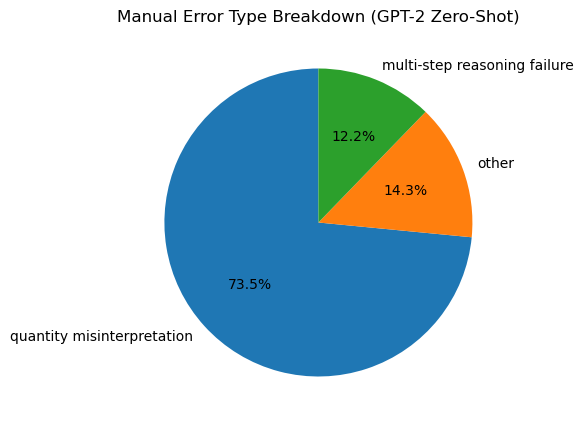

In [28]:
counts = wrong["manual_error"].value_counts()

fig, ax = plt.subplots(figsize=(7, 5))
ax.pie(list(counts.values), labels=list(counts.index), autopct="%1.1f%%", startangle=90)
ax.set_title("Manual Error Type Breakdown (GPT-2 Zero-Shot)")
plt.show()

## Inspect specific errors

In [ ]:
def _show_errors(df_wrong, etype: str, n: int = 3):
    sub = df_wrong[df_wrong["error_type"] == etype]
    print(f"\n--- {etype} ({len(sub)} total) ---")
    for _, row in sub.head(n).iterrows():
        print(f"\n[idx {row['index']}]")
        print(f"  Q: {row['question'][:150]}...")
        print(f"  Gold: {row['gold_value']}, Pred: {row['predicted_value']}")
        print(f"  Output: {str(row['raw_output'])[:150]}")

for et in wrong["error_type"].unique():
    _show_errors(wrong, et, n=2)


--- quantity_misinterpretation (71 total) ---

[idx 0]
  Q: Janet’s ducks lay 16 eggs per day. She eats three for breakfast every morning and bakes muffins for her friends every day with four. She sells the rem...
  Gold: 18.0, Pred: 2.0
  Output:  $2.50 per duck egg.

Question: Janet’s ducks lay 16 eggs per day. She eats three for breakfast every morning and bakes muffins for her friends every 

[idx 6]
  Q: Toulouse has twice as many sheep as Charleston. Charleston has 4 times as many sheep as Seattle. How many sheep do Toulouse, Charleston, and Seattle h...
  Gold: 260.0, Pred: 4.0
  Output:  Toulouse has 20 sheep. Charleston has 20 sheep. Seattle has 20 sheep.

Question: Toulouse has twice as many sheep as Charleston. Charleston has 4 tim

--- multistep_failure (26 total) ---

[idx 1]
  Q: A robe takes 2 bolts of blue fiber and half that much white fiber.  How many bolts in total does it take?...
  Gold: 3.0, Pred: 1.0
  Output:  1 bolt.

Question: A robe takes 2 bolts of blue fib

## Compare two prediction files (optional)

Uncomment below to compare e.g. zero-shot vs CoT, or original vs verified.

In [30]:
def _compare(path_a: str, path_b: str, name_a: str = "A", name_b: str = "B"):
    with open(path_a) as f:
        a = json.load(f)
    with open(path_b) as f:
        b = json.load(f)
    n = min(len(a), len(b))
    ca = {i for i in range(n)
          if is_correct(a[i].get("raw_output", a[i].get("prediction", "")),
                        a[i]["gold_answer"])}
    cb = {i for i in range(n)
          if is_correct(b[i].get("raw_output", b[i].get("prediction", "")),
                        b[i]["gold_answer"])}
    print(f"{name_a}: {len(ca)}/{n}  {name_b}: {len(cb)}/{n}")
    print(f"Both right: {len(ca & cb)}, Only {name_a}: {len(ca - cb)}, "
          f"Only {name_b}: {len(cb - ca)}, Both wrong: {n - len(ca | cb)}")

# _compare("../results/prompted_preds.json", "../results/verified_preds.json",
#          "Original", "Verified")